In [14]:
import numpy as np
import matplotlib.pyplot as plt

from mpi4py import MPI

import ufl
from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dolfinx import geometry

In [2]:
pi = np.pi


def exact_ufl(msh, kind="sin"):
    x = ufl.SpatialCoordinate(msh)

    if kind == "cos":
        u_ex = ufl.cos(pi * x[0]) * ufl.cos(pi * x[1])
    elif kind == "sin":
        u_ex = ufl.sin(pi * x[0]) * ufl.sin(pi * x[1])
    else:
        raise ValueError("kind deve ser 'sin' ou 'cos'.")

    f = 2.0 * pi**2 * u_ex

    return u_ex, f


def exact_numpy(kind="sin"):
    if kind == "cos":
        return lambda x: np.cos(pi * x[0]) * np.cos(pi * x[1])

    if kind == "sin":
        return lambda x: np.sin(pi * x[0]) * np.sin(pi * x[1])

    raise ValueError("kind deve ser 'sin' ou 'cos'.")

In [10]:
def compute_L2_error(msh, uh, u_exact):
    dx = ufl.Measure("dx", domain=msh)

    error_local = fem.assemble_scalar(
        fem.form((uh - u_exact) ** 2 * dx)
    )

    error_global = msh.comm.allreduce(error_local, op=MPI.SUM)

    return np.sqrt(error_global)


def compute_rate(h_old, h_new, err_old, err_new):
    return np.log(err_old / err_new) / np.log(h_old / h_new)


def plot_solution(uh, title="Solução numérica"):
    try:
        import pyvista

        topology, cell_types, geometry = plot.vtk_mesh(uh.function_space)

        grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
        grid.point_data["u_h"] = uh.x.array.real

        plotter = pyvista.Plotter()
        plotter.add_mesh(
            grid,
            scalars="u_h",
            show_edges=True,
            cmap="viridis",
        )
        plotter.add_title(title)
        plotter.view_xy()
        plotter.show()

    except Exception as e:
        print("Não foi possível usar pyvista para plotar.")
        print(e)

In [4]:
def solve_galerkin_2d(n=16, degree=1, kind="sin"):
    comm = MPI.COMM_WORLD

    msh = mesh.create_unit_square(
        comm,
        n,
        n,
        cell_type=mesh.CellType.triangle,
    )

    V = fem.functionspace(msh, ("Lagrange", degree))

    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    u_exact, f = exact_ufl(msh, kind)

    dx = ufl.Measure("dx", domain=msh)

    a = ufl.dot(ufl.grad(u), ufl.grad(v)) * dx
    L = f * v * dx

    # Condição de Dirichlet forte
    g = fem.Function(V)
    g.interpolate(exact_numpy(kind))

    fdim = msh.topology.dim - 1
    boundary_facets = mesh.locate_entities_boundary(
        msh,
        fdim,
        lambda x: np.full(x.shape[1], True, dtype=bool),
    )

    dofs = fem.locate_dofs_topological(V, fdim, boundary_facets)
    bc = fem.dirichletbc(g, dofs)

    problem = LinearProblem(
        a,
        L,
        bcs=[bc],
        petsc_options_prefix=f"galerkin_n{n}_k{degree}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    uh = problem.solve()
    error = compute_L2_error(msh, uh, u_exact)

    return msh, uh, error

In [5]:
def solve_nitsche_2d(n=16, degree=1, alpha=-1.0, beta0=10.0, kind="cos"):
    comm = MPI.COMM_WORLD

    msh = mesh.create_unit_square(
        comm,
        n,
        n,
        cell_type=mesh.CellType.triangle,
    )

    V = fem.functionspace(msh, ("Lagrange", degree))

    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    u_exact, f = exact_ufl(msh, kind)
    g = u_exact

    dx = ufl.Measure("dx", domain=msh)
    ds = ufl.Measure("ds", domain=msh)

    n_vec = ufl.FacetNormal(msh)
    h = ufl.CellDiameter(msh)

    beta = beta0 * degree**2 / h

    a = (
        ufl.dot(ufl.grad(u), ufl.grad(v)) * dx
        - ufl.dot(ufl.grad(u), n_vec) * v * ds
        + alpha * ufl.dot(ufl.grad(v), n_vec) * u * ds
        + beta * u * v * ds
    )

    L = (
        f * v * dx
        + alpha * ufl.dot(ufl.grad(v), n_vec) * g * ds
        + beta * g * v * ds
    )

    problem = LinearProblem(
        a,
        L,
        bcs=[],
        petsc_options_prefix=f"nitsche_n{n}_k{degree}_a{int(alpha)}_b{int(beta0)}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    uh = problem.solve()
    error = compute_L2_error(msh, uh, u_exact)

    return msh, uh, error

In [6]:
def experiment_nitsche_b():
    n = 16
    degree = 1

    alphas = [-1.0, 0.0, 1.0]
    betas = [0.0, 1.0, 10.0, 100.0]

    print("RESULTADOS - MÉTODO DE NITSCHE 2D")
    print("-" * 60)
    print(f"{'alpha':<10} | {'beta0':<10} | {'Erro L2':<15}")
    print("-" * 60)

    results = []

    for alpha in alphas:
        for beta0 in betas:
            msh, uh, error = solve_nitsche_2d(
                n=n,
                degree=degree,
                alpha=alpha,
                beta0=beta0,
                kind="cos",
            )

            results.append((alpha, beta0, error))

            print(f"{alpha:<10.1f} | {beta0:<10.1f} | {error:<15.6e}")

    print("-" * 60)

    return results

In [7]:
results_nitsche = experiment_nitsche_b()

RESULTADOS - MÉTODO DE NITSCHE 2D
------------------------------------------------------------
alpha      | beta0      | Erro L2        
------------------------------------------------------------
-1.0       | 0.0        | inf            
-1.0       | 1.0        | 2.234802e-02   
-1.0       | 10.0       | 3.900737e-03   
-1.0       | 100.0      | 4.116907e-03   
0.0        | 0.0        | inf            
0.0        | 1.0        | 9.141992e-03   
0.0        | 10.0       | 3.486986e-03   
0.0        | 100.0      | 4.066650e-03   
1.0        | 0.0        | 1.175064e-02   
1.0        | 1.0        | 6.575335e-03   
1.0        | 10.0       | 3.301748e-03   
1.0        | 100.0      | 4.018949e-03   
------------------------------------------------------------


In [12]:
def sample_function_on_grid(uh, nx=100, ny=100):
    """
    Amostra uma função escalar do FEniCSx em uma grade regular 2D.
    Funciona para soluções CG ou DG escalares.
    """
    msh = uh.function_space.mesh
    tdim = msh.topology.dim

    x_min, x_max = 0.0, 1.0
    y_min, y_max = 0.0, 1.0

    xs = np.linspace(x_min, x_max, nx)
    ys = np.linspace(y_min, y_max, ny)

    X, Y = np.meshgrid(xs, ys)

    points = np.zeros((nx * ny, 3))
    points[:, 0] = X.ravel()
    points[:, 1] = Y.ravel()

    bb_tree = geometry.bb_tree(msh, tdim)

    candidates = geometry.compute_collisions_points(bb_tree, points)
    cells = geometry.compute_colliding_cells(msh, candidates, points)

    values = np.full(nx * ny, np.nan)

    for i in range(nx * ny):
        cell_candidates = cells.links(i)

        if len(cell_candidates) > 0:
            cell = cell_candidates[0]
            values[i] = uh.eval(points[i], cell)[0]

    Z = values.reshape((ny, nx))

    return X, Y, Z

In [21]:
def plot_solution_seaborn(uh, title="Solução numérica", nx=100, ny=100):
    X, Y, Z = sample_function_on_grid(uh, nx=nx, ny=ny)

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        np.flipud(Z),
        cmap="viridis",
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"label": r"$u_h$"}
    )

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.savefig("nitscheFEM_2D/nitsche2D_{}.pdf".format(nx))
    plt.show()

Erro L2 = 0.001038294622493144


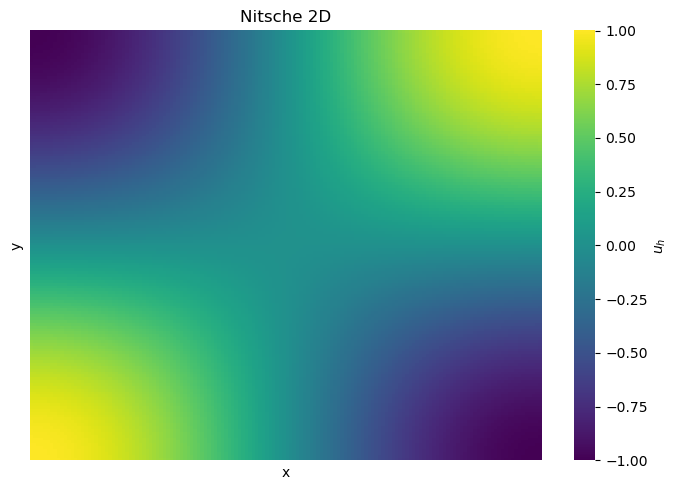

In [22]:
msh, uh, error = solve_nitsche_2d(
    n=32,
    degree=1,
    alpha=-1.0,
    beta0=100.0,
    kind="cos",
)

print("Erro L2 =", error)

plot_solution_seaborn(
    uh,
    title="Nitsche 2D",
    nx=150,
    ny=150
)

In [23]:
def solve_known_lambda_2d(n=16, degree=1, alpha=-1.0, beta0=10.0, kind="cos"):
    comm = MPI.COMM_WORLD

    msh = mesh.create_unit_square(
        comm,
        n,
        n,
        cell_type=mesh.CellType.triangle,
    )

    V = fem.functionspace(msh, ("DG", degree))

    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    u_exact, f = exact_ufl(msh, kind)
    g = u_exact

    dx = ufl.Measure("dx", domain=msh)
    ds = ufl.Measure("ds", domain=msh)
    dS = ufl.Measure("dS", domain=msh)

    n_vec = ufl.FacetNormal(msh)
    h = ufl.CellDiameter(msh)

    beta = beta0 * degree**2 / h

    # Termos de volume
    a = ufl.dot(ufl.grad(u), ufl.grad(v)) * dx
    L = f * v * dx

    # Termos nas faces do contorno externo
    a += (
        - ufl.dot(ufl.grad(u), n_vec) * v * ds
        + alpha * ufl.dot(ufl.grad(v), n_vec) * u * ds
        + beta * u * v * ds
    )

    L += (
        alpha * ufl.dot(ufl.grad(v), n_vec) * g * ds
        + beta * g * v * ds
    )

    # Termos nas faces internas, tratados elemento a elemento
    a += (
        - ufl.dot(ufl.grad(u)("+"), n_vec("+")) * v("+") * dS
        - ufl.dot(ufl.grad(u)("-"), n_vec("-")) * v("-") * dS
    )

    a += alpha * (
        ufl.dot(ufl.grad(v)("+"), n_vec("+")) * u("+")
        + ufl.dot(ufl.grad(v)("-"), n_vec("-")) * u("-")
    ) * dS

    a += (
        beta("+") * u("+") * v("+")
        + beta("-") * u("-") * v("-")
    ) * dS

    # lambda conhecido = solução exata nas faces internas
    L += alpha * (
        ufl.dot(ufl.grad(v)("+"), n_vec("+")) * u_exact("+")
        + ufl.dot(ufl.grad(v)("-"), n_vec("-")) * u_exact("-")
    ) * dS

    L += (
        beta("+") * u_exact("+") * v("+")
        + beta("-") * u_exact("-") * v("-")
    ) * dS

    problem = LinearProblem(
        a,
        L,
        bcs=[],
        petsc_options_prefix=f"known_lambda_n{n}_k{degree}_a{int(alpha)}_b{int(beta0)}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    uh = problem.solve()
    error = compute_L2_error(msh, uh, u_exact)

    return msh, uh, error

In [24]:
def experiment_known_lambda_d():
    n = 16
    degree = 1

    alphas = [-1.0, 0.0, 1.0]
    betas = [0.0, 1.0, 10.0, 100.0]

    print("RESULTADOS - FORMULAÇÃO DESCONTÍNUA COM LAMBDA CONHECIDO")
    print("-" * 60)
    print(f"{'alpha':<10} | {'beta0':<10} | {'Erro L2':<15}")
    print("-" * 60)

    results = []

    for alpha in alphas:
        for beta0 in betas:
            msh, uh, error = solve_known_lambda_2d(
                n=n,
                degree=degree,
                alpha=alpha,
                beta0=beta0,
                kind="cos",
            )

            results.append((alpha, beta0, error))

            print(f"{alpha:<10.1f} | {beta0:<10.1f} | {error:<15.6e}")

    print("-" * 60)

    return results

In [25]:
results_known_lambda = experiment_known_lambda_d()

RESULTADOS - FORMULAÇÃO DESCONTÍNUA COM LAMBDA CONHECIDO
------------------------------------------------------------
alpha      | beta0      | Erro L2        
------------------------------------------------------------
-1.0       | 0.0        | inf            
-1.0       | 1.0        | 7.109462e-03   
-1.0       | 10.0       | 1.429993e-03   
-1.0       | 100.0      | 1.609077e-03   
0.0        | 0.0        | inf            
0.0        | 1.0        | 7.237918e-03   
0.0        | 10.0       | 1.332762e-03   
0.0        | 100.0      | 1.609827e-03   
1.0        | 0.0        | inf            
1.0        | 1.0        | 7.081500e-03   
1.0        | 10.0       | 1.345277e-03   
1.0        | 100.0      | 1.611026e-03   
------------------------------------------------------------


In [26]:
def solve_dg_2d(n=16, degree=1, alpha=-1.0, beta0=10.0, kind="sin"):
    comm = MPI.COMM_WORLD

    msh = mesh.create_unit_square(
        comm,
        n,
        n,
        cell_type=mesh.CellType.triangle,
    )

    V = fem.functionspace(msh, ("DG", degree))

    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    u_exact, f = exact_ufl(msh, kind)
    g = u_exact

    dx = ufl.Measure("dx", domain=msh)
    ds = ufl.Measure("ds", domain=msh)
    dS = ufl.Measure("dS", domain=msh)

    n_vec = ufl.FacetNormal(msh)
    h = ufl.CellDiameter(msh)

    h_avg = 0.5 * (h("+") + h("-"))

    beta_int = beta0 * degree**2 / h_avg
    beta_ext = beta0 * degree**2 / h

    a = ufl.dot(ufl.grad(u), ufl.grad(v)) * dx
    L = f * v * dx

    # Faces internas
    a += -ufl.dot(ufl.avg(ufl.grad(u)), ufl.jump(v, n_vec)) * dS
    a += alpha * ufl.dot(ufl.avg(ufl.grad(v)), ufl.jump(u, n_vec)) * dS
    a += beta_int * ufl.dot(ufl.jump(u, n_vec), ufl.jump(v, n_vec)) * dS

    # Contorno externo: Nitsche
    a += (
        - ufl.dot(ufl.grad(u), n_vec) * v * ds
        + alpha * ufl.dot(ufl.grad(v), n_vec) * u * ds
        + beta_ext * u * v * ds
    )

    L += (
        alpha * ufl.dot(ufl.grad(v), n_vec) * g * ds
        + beta_ext * g * v * ds
    )

    problem = LinearProblem(
        a,
        L,
        bcs=[],
        petsc_options_prefix=f"dg_n{n}_k{degree}_a{int(alpha)}_b{int(beta0)}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    uh = problem.solve()
    error = compute_L2_error(msh, uh, u_exact)

    return msh, uh, error

In [27]:
def convergence_study(method, degrees=[1, 2, 3, 4], ns=[4, 8, 16, 32], alpha=-1.0, beta0=10.0):
    print(f"ESTUDO DE CONVERGÊNCIA - {method.upper()}")
    print("-" * 80)
    print(f"{'k':<4} | {'n':<6} | {'h':<12} | {'Erro L2':<15} | {'Taxa':<10}")
    print("-" * 80)

    results = []

    for degree in degrees:
        prev_h = None
        prev_error = None

        for n in ns:
            h = 1.0 / n

            if method == "galerkin":
                msh, uh, error = solve_galerkin_2d(
                    n=n,
                    degree=degree,
                    kind="sin",
                )

            elif method == "nitsche":
                msh, uh, error = solve_nitsche_2d(
                    n=n,
                    degree=degree,
                    alpha=alpha,
                    beta0=beta0,
                    kind="sin",
                )

            elif method == "dg":
                msh, uh, error = solve_dg_2d(
                    n=n,
                    degree=degree,
                    alpha=alpha,
                    beta0=beta0,
                    kind="sin",
                )

            else:
                raise ValueError("method deve ser 'galerkin', 'nitsche' ou 'dg'.")

            if prev_error is None:
                rate = "-"
            else:
                rate = compute_rate(prev_h, h, prev_error, error)

            results.append((degree, n, h, error, rate))

            if rate == "-":
                print(f"{degree:<4} | {n:<6} | {h:<12.4e} | {error:<15.6e} | {'-':<10}")
            else:
                print(f"{degree:<4} | {n:<6} | {h:<12.4e} | {error:<15.6e} | {rate:<10.4f}")

            prev_h = h
            prev_error = error

        print("-" * 80)

    return results

In [28]:
results_galerkin = convergence_study(
    method="galerkin",
    degrees=[1, 2, 3, 4],
    ns=[4, 8, 16, 32],
)

ESTUDO DE CONVERGÊNCIA - GALERKIN
--------------------------------------------------------------------------------
k    | n      | h            | Erro L2         | Taxa      
--------------------------------------------------------------------------------
1    | 4      | 2.5000e-01   | 7.907545e-02    | -         
1    | 8      | 1.2500e-01   | 2.113277e-02    | 1.9037    
1    | 16     | 6.2500e-02   | 5.377435e-03    | 1.9745    
1    | 32     | 3.1250e-02   | 1.350436e-03    | 1.9935    
--------------------------------------------------------------------------------
2    | 4      | 2.5000e-01   | 4.327631e-03    | -         
2    | 8      | 1.2500e-01   | 5.480619e-04    | 2.9812    
2    | 16     | 6.2500e-02   | 6.873916e-05    | 2.9951    
2    | 32     | 3.1250e-02   | 8.600535e-06    | 2.9986    
--------------------------------------------------------------------------------
3    | 4      | 2.5000e-01   | 3.361701e-04    | -         
3    | 8      | 1.2500e-01   | 1.999608e-0

In [29]:
results_nitsche_conv = convergence_study(
    method="nitsche",
    degrees=[1, 2, 3, 4],
    ns=[4, 8, 16, 32],
    alpha=-1.0,
    beta0=10.0,
)

ESTUDO DE CONVERGÊNCIA - NITSCHE
--------------------------------------------------------------------------------
k    | n      | h            | Erro L2         | Taxa      
--------------------------------------------------------------------------------
1    | 4      | 2.5000e-01   | 6.064534e-02    | -         
1    | 8      | 1.2500e-01   | 1.899956e-02    | 1.6744    
1    | 16     | 6.2500e-02   | 5.122726e-03    | 1.8910    
1    | 32     | 3.1250e-02   | 1.318967e-03    | 1.9575    
--------------------------------------------------------------------------------
2    | 4      | 2.5000e-01   | 3.834813e-03    | -         
2    | 8      | 1.2500e-01   | 5.145843e-04    | 2.8977    
2    | 16     | 6.2500e-02   | 6.662108e-05    | 2.9494    
2    | 32     | 3.1250e-02   | 8.468398e-06    | 2.9758    
--------------------------------------------------------------------------------
3    | 4      | 2.5000e-01   | 3.169055e-04    | -         
3    | 8      | 1.2500e-01   | 1.944498e-05

In [30]:
results_dg = convergence_study(
    method="dg",
    degrees=[1, 2, 3, 4],
    ns=[4, 8, 16, 32],
    alpha=-1.0,
    beta0=10.0,
)

ESTUDO DE CONVERGÊNCIA - DG
--------------------------------------------------------------------------------
k    | n      | h            | Erro L2         | Taxa      
--------------------------------------------------------------------------------
1    | 4      | 2.5000e-01   | 4.217939e-02    | -         
1    | 8      | 1.2500e-01   | 1.282434e-02    | 1.7177    
1    | 16     | 6.2500e-02   | 3.477783e-03    | 1.8826    
1    | 32     | 3.1250e-02   | 8.999740e-04    | 1.9502    
--------------------------------------------------------------------------------
2    | 4      | 2.5000e-01   | 3.297893e-03    | -         
2    | 8      | 1.2500e-01   | 4.170214e-04    | 2.9834    
2    | 16     | 6.2500e-02   | 5.253237e-05    | 2.9888    
2    | 32     | 3.1250e-02   | 6.599163e-06    | 2.9929    
--------------------------------------------------------------------------------
3    | 4      | 2.5000e-01   | 2.987678e-04    | -         
3    | 8      | 1.2500e-01   | 1.841661e-05    |

Erro Galerkin = 8.600535271297473e-06


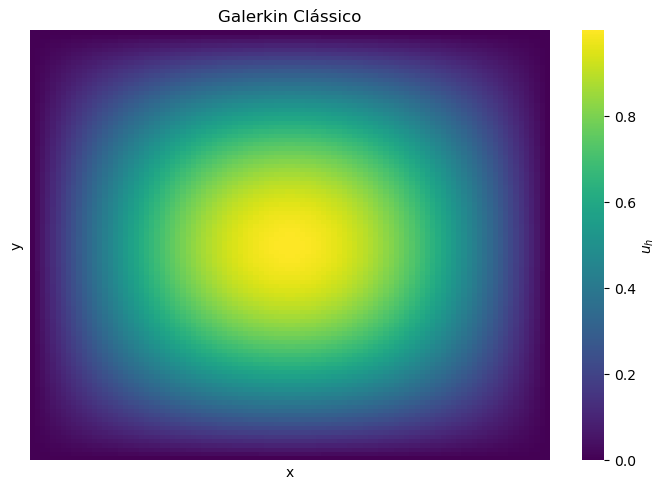

In [32]:
msh, uh_gal, error_gal = solve_galerkin_2d(
    n=32,
    degree=2,
    kind="sin",
)

print("Erro Galerkin =", error_gal)
plot_solution_seaborn(uh=uh_gal, title="Galerkin Clássico")

Erro DG = 6.599162501693149e-06


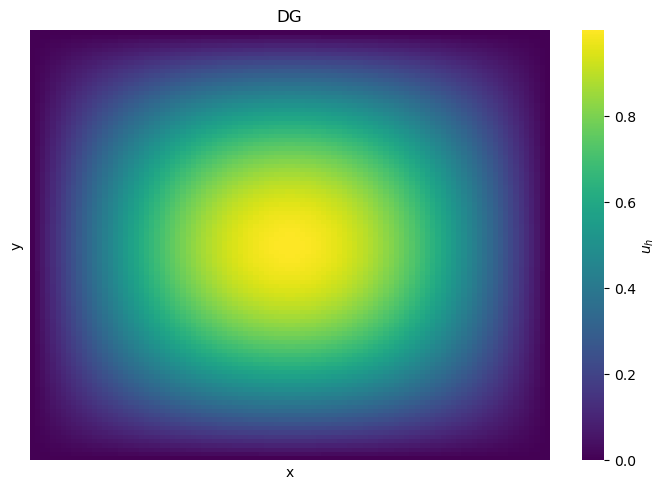

In [33]:
msh, uh_dg, error_dg = solve_dg_2d(
    n=32,
    degree=2,
    alpha=-1.0,
    beta0=10.0,
    kind="sin",
)

print("Erro DG =", error_dg)
plot_solution_seaborn(uh=uh_gal, title="DG")

# Condensação Estática

In [39]:
import numpy as np
import matplotlib.pyplot as plt

from mpi4py import MPI
from petsc4py import PETSc

import ufl
from dolfinx import fem, mesh, geometry
from dolfinx.cpp.mesh import cell_num_entities
from dolfinx.fem.petsc import assemble_matrix, assemble_vector

from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse.linalg import spsolve

In [40]:
pi = np.pi


def exact_ufl(msh, kind="sin"):
    x = ufl.SpatialCoordinate(msh)

    if kind == "sin":
        u_ex = ufl.sin(pi * x[0]) * ufl.sin(pi * x[1])
    elif kind == "cos":
        u_ex = ufl.cos(pi * x[0]) * ufl.cos(pi * x[1])
    else:
        raise ValueError("kind deve ser 'sin' ou 'cos'.")

    # f = -Delta u
    f = 2.0 * pi**2 * u_ex

    return u_ex, f


def exact_numpy(kind="sin"):
    def u_ex(x):
        if kind == "sin":
            return np.sin(pi * x[0]) * np.sin(pi * x[1])
        elif kind == "cos":
            return np.cos(pi * x[0]) * np.cos(pi * x[1])
        else:
            raise ValueError("kind deve ser 'sin' ou 'cos'.")

    return u_ex

In [41]:
def compute_cell_boundary_facets(msh):
    """
    Retorna pares (célula, faceta local) para integrar em dK.
    Isso permite integrar no contorno de cada elemento.
    """
    tdim = msh.topology.dim
    fdim = tdim - 1

    n_facets_per_cell = cell_num_entities(msh.topology.cell_type, fdim)
    n_cells = msh.topology.index_map(tdim).size_local

    entities = np.vstack((
        np.repeat(np.arange(n_cells), n_facets_per_cell),
        np.tile(np.arange(n_facets_per_cell), n_cells)
    )).T.flatten()

    return entities

In [42]:
def petsc_to_scipy(A):
    """
    Converte matriz PETSc AIJ para scipy csr_matrix.
    """
    indptr, indices, data = A.getValuesCSR()
    return csr_matrix((data, indices, indptr), shape=A.getSize())

In [43]:
def create_hybrid_spaces(n=8, degree=1):
    """
    Cria:
    - malha 2D no quadrado unitário;
    - submalha formada por todas as facetas;
    - espaço DG para u;
    - espaço DG nas facetas para lambda.
    """

    comm = MPI.COMM_SELF

    msh = mesh.create_unit_square(
        comm,
        n,
        n,
        cell_type=mesh.CellType.triangle,
        ghost_mode=mesh.GhostMode.none,
    )

    tdim = msh.topology.dim
    fdim = tdim - 1

    msh.topology.create_entities(fdim)
    msh.topology.create_connectivity(tdim, fdim)
    msh.topology.create_connectivity(fdim, tdim)

    facet_imap = msh.topology.index_map(fdim)
    num_facets = facet_imap.size_local + facet_imap.num_ghosts

    facets = np.arange(num_facets, dtype=np.int32)

    # Em versões novas, create_submesh retorna:
    # facet_mesh, facet_mesh_emap, vertex_map, geom_map
    submesh_data = mesh.create_submesh(msh, fdim, facets)

    facet_mesh = submesh_data[0]
    facet_map = submesh_data[1]

    V = fem.functionspace(msh, ("Discontinuous Lagrange", degree))
    M = fem.functionspace(facet_mesh, ("Discontinuous Lagrange", degree))

    return msh, facet_mesh, facet_map, V, M

In [44]:
def create_entity_maps(msh, facet_mesh, facet_map):
    """
    Cria o entity_maps para montar formas envolvendo msh e facet_mesh.
    Também cria função para converter facetas da malha principal para células da facet_mesh.
    """

    fdim = msh.topology.dim - 1

    facet_imap = msh.topology.index_map(fdim)
    num_facets = facet_imap.size_local + facet_imap.num_ghosts

    # FEniCSx novo: facet_map é EntityMap
    if hasattr(facet_map, "sub_topology_to_topology"):
        entity_maps = [facet_map]

        def parent_facets_to_submesh(parent_facets):
            return facet_map.sub_topology_to_topology(parent_facets, inverse=True)

    # FEniCSx antigo: facet_map pode ser array submesh -> mesh
    else:
        facet_mesh_to_mesh = facet_map

        mesh_to_facet_mesh = np.full(num_facets, -1, dtype=np.int32)
        mesh_to_facet_mesh[facet_mesh_to_mesh] = np.arange(
            len(facet_mesh_to_mesh),
            dtype=np.int32
        )

        entity_maps = {facet_mesh: mesh_to_facet_mesh}

        def parent_facets_to_submesh(parent_facets):
            return mesh_to_facet_mesh[parent_facets]

    return entity_maps, parent_facets_to_submesh

In [45]:
def build_hybrid_forms(
    msh,
    facet_mesh,
    facet_map,
    V,
    M,
    degree=1,
    alpha=-1.0,
    beta0=10.0,
    kind="sin",
):
    """
    Monta a formulação híbrida:

    A U + B Lambda = F
    D U + C Lambda = G

    com lambda definido nas facetas.
    """

    W = ufl.MixedFunctionSpace(V, M)

    u, lamb = ufl.TrialFunctions(W)
    v, mu = ufl.TestFunctions(W)

    dx = ufl.Measure("dx", domain=msh)

    cell_boundary_facets = compute_cell_boundary_facets(msh)
    cell_boundaries = 1

    dsK = ufl.Measure(
        "ds",
        domain=msh,
        subdomain_data=[(cell_boundaries, cell_boundary_facets)]
    )

    dx_facet = ufl.Measure("dx", domain=facet_mesh)

    n_vec = ufl.FacetNormal(msh)
    h = ufl.CellDiameter(msh)

    beta = beta0 * degree**2 / h

    u_exact, f = exact_ufl(msh, kind)

    # Forma compacta do método híbrido:
    #
    # int_K grad(u).grad(v)
    # - int_dK grad(u).n (v - mu)
    # + alpha int_dK grad(v).n (u - lambda)
    # + beta int_dK (u - lambda)(v - mu)
    a = (
        ufl.inner(ufl.grad(u), ufl.grad(v)) * dx
        - ufl.dot(ufl.grad(u), n_vec) * (v - mu) * dsK(cell_boundaries)
        + alpha * ufl.dot(ufl.grad(v), n_vec) * (u - lamb) * dsK(cell_boundaries)
        + beta * (u - lamb) * (v - mu) * dsK(cell_boundaries)
    )

    L = f * v * dx

    # Termo zero só para criar o bloco do multiplicador no vetor.
    zero = fem.Constant(facet_mesh, PETSc.ScalarType(0.0))
    L += zero * mu * dx_facet

    entity_maps, parent_facets_to_submesh = create_entity_maps(
        msh,
        facet_mesh,
        facet_map
    )

    a_blocked = fem.form(
        ufl.extract_blocks(a),
        entity_maps=entity_maps
    )

    L_blocked = fem.form(
        ufl.extract_blocks(L)
    )

    return a_blocked, L_blocked, parent_facets_to_submesh

In [46]:
def assemble_hybrid_blocks(n=8, degree=1, alpha=-1.0, beta0=10.0, kind="sin"):
    msh, facet_mesh, facet_map, V, M = create_hybrid_spaces(
        n=n,
        degree=degree
    )

    a_blocked, L_blocked, parent_facets_to_submesh = build_hybrid_forms(
        msh,
        facet_mesh,
        facet_map,
        V,
        M,
        degree=degree,
        alpha=alpha,
        beta0=beta0,
        kind=kind,
    )

    A_petsc = assemble_matrix(a_blocked, bcs=[])
    A_petsc.assemble()

    b_petsc = assemble_vector(L_blocked)
    b_petsc.ghostUpdate(
        addv=PETSc.InsertMode.ADD,
        mode=PETSc.ScatterMode.REVERSE
    )

    A_full = petsc_to_scipy(A_petsc)
    b_full = b_petsc.array.copy()

    ndofs_u = V.dofmap.index_map.size_local * V.dofmap.index_map_bs
    ndofs_l = M.dofmap.index_map.size_local * M.dofmap.index_map_bs

    A = A_full[:ndofs_u, :ndofs_u]
    B = A_full[:ndofs_u, ndofs_u:ndofs_u + ndofs_l]
    D = A_full[ndofs_u:ndofs_u + ndofs_l, :ndofs_u]
    C = A_full[ndofs_u:ndofs_u + ndofs_l, ndofs_u:ndofs_u + ndofs_l]

    F = b_full[:ndofs_u]
    G = b_full[ndofs_u:ndofs_u + ndofs_l]

    return {
        "msh": msh,
        "facet_mesh": facet_mesh,
        "facet_map": facet_map,
        "V": V,
        "M": M,
        "A": A,
        "B": B,
        "D": D,
        "C": C,
        "F": F,
        "G": G,
        "parent_facets_to_submesh": parent_facets_to_submesh,
    }

In [47]:
def get_cell_lambda_dofs(data, cell):
    """
    Retorna os dofs globais de lambda associados às facetas da célula.
    """

    msh = data["msh"]
    facet_mesh = data["facet_mesh"]
    M = data["M"]
    parent_facets_to_submesh = data["parent_facets_to_submesh"]

    tdim = msh.topology.dim
    fdim = tdim - 1

    msh.topology.create_connectivity(tdim, fdim)

    cell_to_facet = msh.topology.connectivity(tdim, fdim)
    parent_facets = cell_to_facet.links(cell)

    sub_facets = parent_facets_to_submesh(parent_facets)

    lambda_dofs = []

    for sf in sub_facets:
        dofs = M.dofmap.cell_dofs(int(sf))
        lambda_dofs.extend(dofs)

    return np.array(lambda_dofs, dtype=np.int32)

In [48]:
def lambda_boundary_dofs_and_values(data, kind="sin"):
    """
    Como lambda representa o traço de u, no contorno impomos lambda = g.
    """

    msh = data["msh"]
    facet_mesh = data["facet_mesh"]
    M = data["M"]
    parent_facets_to_submesh = data["parent_facets_to_submesh"]

    fdim = msh.topology.dim - 1

    boundary_facets_parent = mesh.exterior_facet_indices(msh.topology)
    boundary_facets_submesh = parent_facets_to_submesh(boundary_facets_parent)

    facet_mesh.topology.create_connectivity(fdim, fdim)

    dofs = fem.locate_dofs_topological(
        M,
        fdim,
        boundary_facets_submesh
    )

    g = fem.Function(M)
    g.interpolate(exact_numpy(kind))

    values = g.x.array[dofs].copy()

    return np.array(dofs, dtype=np.int32), values

In [49]:
def apply_dirichlet_scipy(S, rhs, dofs, values):
    """
    Impõe Dirichlet em S lambda = rhs.
    """

    S = S.tolil()
    rhs = rhs.copy()

    # Ajusta lado direito por causa das colunas de Dirichlet
    rhs -= S[:, dofs] @ values

    # Zera colunas
    S[:, dofs] = 0.0

    # Linhas identidade
    for dof, value in zip(dofs, values):
        S.rows[int(dof)] = [int(dof)]
        S.data[int(dof)] = [1.0]
        rhs[int(dof)] = value

    return S.tocsr(), rhs

In [50]:
def static_condensation(data):
    """
    Monta o sistema condensado:

        S Lambda = rhs

    eliminando os graus de liberdade de u localmente.
    """

    msh = data["msh"]
    V = data["V"]

    A = data["A"]
    B = data["B"]
    D = data["D"]
    C = data["C"]
    F = data["F"]
    G = data["G"]

    tdim = msh.topology.dim
    num_cells = msh.topology.index_map(tdim).size_local

    # Começa com o bloco C global já montado corretamente pelo FEniCSx
    S = C.copy().tolil()
    rhs = G.copy()

    for cell in range(num_cells):
        u_dofs = V.dofmap.cell_dofs(cell)
        lambda_dofs = get_cell_lambda_dofs(data, cell)

        A_K = A[u_dofs, :][:, u_dofs].toarray()
        B_K = B[u_dofs, :][:, lambda_dofs].toarray()
        D_K = D[lambda_dofs, :][:, u_dofs].toarray()
        F_K = F[u_dofs]

        Ainv_B = np.linalg.solve(A_K, B_K)
        Ainv_F = np.linalg.solve(A_K, F_K)

        S_K = -D_K @ Ainv_B
        rhs_K = -D_K @ Ainv_F

        for i_local, i_global in enumerate(lambda_dofs):
            rhs[i_global] += rhs_K[i_local]

            for j_local, j_global in enumerate(lambda_dofs):
                S[i_global, j_global] += S_K[i_local, j_local]

    return S.tocsr(), rhs

In [51]:
def recover_u(data, Lambda):
    """
    Recupera u_h elemento por elemento depois de resolver lambda.
    """

    msh = data["msh"]
    V = data["V"]

    A = data["A"]
    B = data["B"]
    F = data["F"]

    tdim = msh.topology.dim
    num_cells = msh.topology.index_map(tdim).size_local

    U = np.zeros(V.dofmap.index_map.size_local * V.dofmap.index_map_bs)

    for cell in range(num_cells):
        u_dofs = V.dofmap.cell_dofs(cell)
        lambda_dofs = get_cell_lambda_dofs(data, cell)

        A_K = A[u_dofs, :][:, u_dofs].toarray()
        B_K = B[u_dofs, :][:, lambda_dofs].toarray()
        F_K = F[u_dofs]

        Lambda_K = Lambda[lambda_dofs]

        U_K = np.linalg.solve(A_K, F_K - B_K @ Lambda_K)

        U[u_dofs] = U_K

    uh = fem.Function(V, name="u_h")
    uh.x.array[:] = U
    uh.x.scatter_forward()

    return uh

In [52]:
def solve_hybrid_condensed_2d(
    n=8,
    degree=1,
    alpha=-1.0,
    beta0=10.0,
    kind="sin",
):
    data = assemble_hybrid_blocks(
        n=n,
        degree=degree,
        alpha=alpha,
        beta0=beta0,
        kind=kind,
    )

    S, rhs = static_condensation(data)

    bdofs, bvalues = lambda_boundary_dofs_and_values(data, kind=kind)

    S_bc, rhs_bc = apply_dirichlet_scipy(
        S,
        rhs,
        bdofs,
        bvalues
    )

    Lambda = spsolve(S_bc, rhs_bc)

    uh = recover_u(data, Lambda)

    lambdah = fem.Function(data["M"], name="lambda_h")
    lambdah.x.array[:] = Lambda
    lambdah.x.scatter_forward()

    u_exact, _ = exact_ufl(data["msh"], kind)

    error_local = fem.assemble_scalar(
        fem.form((uh - u_exact) ** 2 * ufl.dx)
    )

    error = np.sqrt(data["msh"].comm.allreduce(error_local, op=MPI.SUM))

    return data["msh"], data["facet_mesh"], uh, lambdah, error

In [53]:
msh, facet_mesh, uh, lambdah, error = solve_hybrid_condensed_2d(
    n=8,
    degree=1,
    alpha=-1.0,
    beta0=10.0,
    kind="sin",
)

print("Erro L2 =", error)
print("DOFs u      =", uh.function_space.dofmap.index_map.size_local)
print("DOFs lambda =", lambdah.function_space.dofmap.index_map.size_local)

Erro L2 = 0.0055957539527062205
DOFs u      = 384
DOFs lambda = 416


In [54]:
def convergence_hybrid_condensed_2d(
    degrees=[1, 2, 3, 4],
    ns=[4, 8, 16, 32],
    alphas=[-1.0, 0.0, 1.0],
    beta0=10.0,
    kind="sin",
):
    all_results = {}

    for alpha in alphas:
        print()
        print("=" * 90)
        print(f"Condensação estática 2D - alpha = {alpha}")
        print("=" * 90)

        results_alpha = []

        for degree in degrees:
            print()
            print(f"===== k = {degree} =====")
            print(f"{'n':<8} | {'h':<12} | {'Erro L2':<14} | {'Taxa':<10}")
            print("-" * 60)

            previous_h = None
            previous_error = None

            for n in ns:
                h = 1.0 / n

                msh, facet_mesh, uh, lambdah, error = solve_hybrid_condensed_2d(
                    n=n,
                    degree=degree,
                    alpha=alpha,
                    beta0=beta0,
                    kind=kind,
                )

                if previous_error is None:
                    rate = "-"
                else:
                    rate = np.log(previous_error / error) / np.log(previous_h / h)

                results_alpha.append((degree, n, h, error, rate))

                if rate == "-":
                    print(f"{n:<8} | {h:<12.4e} | {error:<14.6e} | {'-':<10}")
                else:
                    print(f"{n:<8} | {h:<12.4e} | {error:<14.6e} | {rate:<10.4f}")

                previous_h = h
                previous_error = error

        all_results[alpha] = results_alpha

    return all_results

In [55]:
results_test = convergence_hybrid_condensed_2d(
    degrees=[1],
    ns=[4, 8, 16],
    alphas=[-1.0],
    beta0=10.0,
    kind="sin",
)


Condensação estática 2D - alpha = -1.0

===== k = 1 =====
n        | h            | Erro L2        | Taxa      
------------------------------------------------------------
4        | 2.5000e-01   | 2.246784e-02   | -         
8        | 1.2500e-01   | 5.595754e-03   | 2.0055    
16       | 6.2500e-02   | 1.397194e-03   | 2.0018    


In [56]:
results_hybrid = convergence_hybrid_condensed_2d(
    degrees=[1, 2, 3, 4],
    ns=[4, 8, 16, 32],
    alphas=[-1.0, 0.0, 1.0],
    beta0=10.0,
    kind="sin",
)


Condensação estática 2D - alpha = -1.0

===== k = 1 =====
n        | h            | Erro L2        | Taxa      
------------------------------------------------------------
4        | 2.5000e-01   | 2.246784e-02   | -         
8        | 1.2500e-01   | 5.595754e-03   | 2.0055    
16       | 6.2500e-02   | 1.397194e-03   | 2.0018    
32       | 3.1250e-02   | 3.491824e-04   | 2.0005    

===== k = 2 =====
n        | h            | Erro L2        | Taxa      
------------------------------------------------------------
4        | 2.5000e-01   | 2.884970e-03   | -         
8        | 1.2500e-01   | 3.634340e-04   | 2.9888    
16       | 6.2500e-02   | 4.550365e-05   | 2.9976    
32       | 3.1250e-02   | 5.689444e-06   | 2.9996    

===== k = 3 =====
n        | h            | Erro L2        | Taxa      
------------------------------------------------------------
4        | 2.5000e-01   | 2.715269e-04   | -         
8        | 1.2500e-01   | 1.659034e-05   | 4.0327    
16       | 6.2500e

In [58]:
import seaborn as sns


def sample_function_on_grid(uh, nx=120, ny=120):
    msh = uh.function_space.mesh
    tdim = msh.topology.dim

    xs = np.linspace(0.0, 1.0, nx)
    ys = np.linspace(0.0, 1.0, ny)

    X, Y = np.meshgrid(xs, ys)

    points = np.zeros((nx * ny, 3))
    points[:, 0] = X.ravel()
    points[:, 1] = Y.ravel()

    bb_tree = geometry.bb_tree(msh, tdim)

    candidates = geometry.compute_collisions_points(bb_tree, points)
    cells = geometry.compute_colliding_cells(msh, candidates, points)

    values = np.full(nx * ny, np.nan)

    for i in range(nx * ny):
        cell_candidates = cells.links(i)

        if len(cell_candidates) > 0:
            cell = cell_candidates[0]
            values[i] = uh.eval(points[i], cell)[0]

    Z = values.reshape((ny, nx))

    return X, Y, Z


def plot_solution_seaborn(uh, title="Solução numérica", nx=120, ny=120):
    X, Y, Z = sample_function_on_grid(uh, nx=nx, ny=ny)

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        np.flipud(Z),
        cmap="viridis",
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"label": r"$u_h$"}
    )

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.savefig("hybridFEM_2D/plot_condensacao.pdf")
    plt.show()

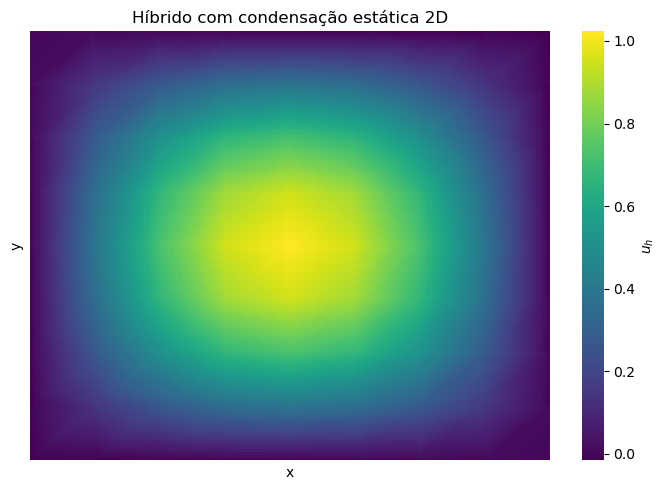

In [59]:
plot_solution_seaborn(
    uh,
    title="Híbrido com condensação estática 2D",
    nx=150,
    ny=150,
)